# Notebook 03: Activation Patching & MLP Ablation

**Research Question:** Which downstream MLP circuits fail to translate 
L1H1's correct modifier attention into correct repetition counts, and 
can patching activations from success cases into failure cases restore 
correct behavior?

**Background from Notebook 02:**
- L1H1 is the primary modifier-tracking head
- Modifier attention is preserved in failure cases (H2 rejected)
- Failure is downstream of attention — likely in MLP circuits

**Hypotheses:**
- H4: Ablating L1H1 increases failure rate 
  (confirms modifier tracking role)
- H5: Patching L1 MLP activations from success → failure cases 
  restores correct repetition counts
- H6: L1 MLP is the primary circuit responsible for translating 
  modifier attention into repetition counts

**Dependencies & Setup**

In [1]:
import sys, os
root_path = os.path.abspath("..")
src_path = os.path.join(root_path, "src")
for path in [root_path, src_path]:
    if path not in sys.path:
        sys.path.append(root_path)

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from jaxtyping import Float, Int
from torch import Tensor
import circuitsvis as cv
from transformer_lens import HookedTransformer, HookedTransformerConfig

from config.config import Config
from src.data import SCANDataModule,SCANTokenizer
from src.model import Transformer
from src.evaluate import Evaluator

## 1. Setup & Load Model
**Goal:** Load trained model, data module, and failure/success cases.
**Output:** Model loaded, cases ready for patching experiments.

In [2]:
cfg = Config()
model = Transformer(cfg)
model.load_state_dict(torch.load("../results/model_final_small.pt"))


dm = SCANDataModule(cfg)
tokenizer = dm.tokenizer

import re
import pandas as pd

def parse_failure_log(filepath):
    """
    Parses SCAN failure logs and returns a list of dictionaries 
    with columns: splitname, command, target, pred.
    """
    # Regex breakdown:
    # \[(.*?)\] -> Captures everything inside the square brackets (splitname)
    # COMMAND:.*?IN:\s*(.*?)\s*OUT: -> Captures everything between IN: and OUT: (command)
    # TARGET:\s*(.*?)\s*\| -> Captures everything between TARGET: and the next | (target)
    # PRED:\s*(.*)$ -> Captures everything after PRED: to the end of the line (pred)
    pattern = re.compile(r"\[(.*?)\]\s*COMMAND:\s*(.*?)\s*\|\s*TARGET:\s*(.*?)\s*\|\s*PRED:\s*(.*)$")
    
    parsed_rows = []
    
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue  # Skip empty lines
                
            match = pattern.search(line)
            if match:
                splitname, command, target, pred = match.groups()
                
                parsed_rows.append({
                    "splitname": splitname,
                    "command": command.strip(),
                    "target": target.strip(),
                    "pred": pred.strip()
                })
                
    return parsed_rows

simple_data = parse_failure_log("../results/small_failure_cases_simple.txt")
length_data = parse_failure_log("../results/small_failure_cases_length.txt")
addprim_jump_data = parse_failure_log("../results/small_failure_cases_addprim_jump.txt")

all_failures = pd.DataFrame(simple_data + length_data + addprim_jump_data)
simple_failures = pd.DataFrame(simple_data)
length_failures = pd.DataFrame(length_data)
addprim_jump_failures = pd.DataFrame(addprim_jump_data)

simple_failures.head()

,splitname,command,target,pred
0,simple,<sos> IN: turn opposite right thrice and turn ...,I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_...,I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_...
1,simple,<sos> IN: look around right twice and turn lef...,I_TURN_RIGHT I_LOOK I_TURN_RIGHT I_LOOK I_TURN...,I_TURN_RIGHT I_LOOK I_TURN_RIGHT I_LOOK I_TURN...
2,simple,<sos> IN: jump around left thrice and run righ...,I_TURN_LEFT I_JUMP I_TURN_LEFT I_JUMP I_TURN_L...,I_TURN_LEFT I_JUMP I_TURN_LEFT I_JUMP I_TURN_L...
3,simple,<sos> IN: jump opposite right after walk aroun...,I_TURN_RIGHT I_WALK I_TURN_RIGHT I_WALK I_TURN...,I_TURN_RIGHT I_WALK I_TURN_RIGHT I_WALK I_TURN...
4,simple,<sos> IN: look opposite right twice and jump o...,I_TURN_RIGHT I_TURN_RIGHT I_LOOK I_TURN_RIGHT ...,I_TURN_RIGHT I_TURN_RIGHT I_LOOK I_TURN_RIGHT ...


In [3]:
hooked_cfg = HookedTransformerConfig(
    n_layers=2,
    n_heads=4,
    d_model=128,       
    d_head=32,          
    d_mlp=512,        
    d_vocab= 25,
    n_ctx=128,          
    act_fn="gelu",      
    normalization_type="LN",
) 

tl_model = HookedTransformer(hooked_cfg)
# Load original custom weights
custom_state_dict = torch.load("../results/model_final_small.pt")

# Build a state dict for TransformerLens
tl_state_dict = {}

# Keep track of IGNORE keys
keys_to_skip = ["tfblocks.0.attn.IGNORE", "tfblocks.1.attn.IGNORE"]

for key, weight in custom_state_dict.items():
    if key in keys_to_skip:
        continue
        
    new_key = key
    
    # Map the layer block prefix: "tfblocks.0..." -> "blocks.0..."
    if new_key.startswith("tfblocks."):
        new_key = new_key.replace("tfblocks.", "blocks.")
        
    # Map the final layer norm: "ln.w" -> "ln_final.w"
    if new_key.startswith("ln."):
        new_key = new_key.replace("ln.", "ln_final.")
        
    # Map token embeddings: "embed.token_embed.weight" -> "embed.W_E"
    if new_key == "embed.token_embed.weight":
        new_key = "embed.W_E"
        
    # Map positional embeddings: "embed.pos_emb.weight" -> "pos_embed.W_pos"
    if new_key == "embed.pos_emb.weight":
        new_key = "pos_embed.W_pos"
        
    tl_state_dict[new_key] = weight

# Handle TransformerLens internal tracking values
# TransformerLens has a couple of default buffers (like mask strings) it initializes itself.
# We set strict=False so it doesn't crash over its own missing 'mask' or 'IGNORE' keys.
missing_keys, unexpected_keys = tl_model.load_state_dict(tl_state_dict, strict=False)

# Verify the load was clean
print("Missing keys:", [k for k in missing_keys if "mask" not in k and "IGNORE" not in k])
print("Unexpected keys:", unexpected_keys)

Missing keys: []
Unexpected keys: []


## 2. Baseline Metrics
**Goal:** Establish baseline failure rates before any intervention.

**Output:** Baseline accuracy per split, failure rate per head.

In [4]:
def generate(
    model: HookedTransformer,
    command: str,
    dm: SCANDataModule,
    cfg: Config,
    max_new_tokens: int = 100
) -> str:
    """Generate action sequence autoregressively using HookedTransformer."""
    input_ids = torch.tensor(
        dm.tokenizer.encode(command),
        dtype=torch.long
    ).unsqueeze(0).to(cfg.device)
    
    pred_ids = []
    with torch.no_grad():
        for _ in range(max_new_tokens):
            input_truncated = input_ids[:, -cfg.max_seq_len:]
            logits = model(input_truncated)
            next_token = torch.argmax(logits[:, -1, :], dim=-1)
            if next_token.item() == dm.tokenizer.token2id["<eos>"]:
                break
            pred_ids.append(next_token.item())
            input_ids = torch.cat(
                [input_ids, next_token.unsqueeze(-1)], dim=-1
            )
    return dm.tokenizer.decode(pred_ids)

In [5]:
def compute_baseline_metrics(
    model: HookedTransformer,
    cases: pd.DataFrame,
    dm: SCANDataModule,
    cfg: Config
) -> dict[str, float]:
    """
    Compute baseline accuracy before any intervention.

    Parameters
    ----------
    model : HookedTransformer
        Loaded model.
    cases : pd.DataFrame
        Test cases to evaluate.
    dm : SCANDataModule
        Data module with tokenizer.
    cfg : Config
        Configuration object.

    Returns
    -------
    dict[str, float]
        Dictionary with keys: accuracy, failure_rate, avg_loss
    """

    correct = 0
    total = 0
    total_loss = []
    
    for _, case in cases.iterrows():
        # Generate using model parameter
        pred = generate(model, case["command"], dm, cfg)
        
        if pred.strip() == case["target"].strip():
            correct += 1
        total += 1
        
        # Compute loss
        full_sequence = case["command"] + " " + case["target"]
        tokens = dm.tokenizer.encode(full_sequence)
        token_ids = torch.tensor(tokens).unsqueeze(0).to(cfg.device)
        
        with torch.no_grad():
            logits = model(token_ids)
            loss = torch.nn.functional.cross_entropy(
                logits[:, :-1, :].reshape(-1, logits.shape[-1]),
                token_ids[:, 1:].reshape(-1)
            )
            total_loss.append(loss.item())
    
    return {
        "accuracy": correct / total,
        "failure_rate": 1 - correct / total,
        "avg_loss": torch.tensor(total_loss).mean().item()
    }

## 3. L1H1 Ablation Experiment
**Goal:** Test H4 — does ablating L1H1 increase failure rate?

**Method:** Zero out L1H1's output using TransformerLens hooks.

**Output:** Failure rate before vs after ablation.

**What ablation means:**
Zeroing L1H1's contribution removes its modifier-tracking signal.
If failure rate increases → L1H1 is causally important.
If failure rate stays same → L1H1 is not causally important.

In [6]:
from functools import partial
from transformer_lens import utils

def ablate_head(
    model: HookedTransformer,
    layer: int,
    head: int,
    token_ids: Int[Tensor, "1 seq_len"],
    cfg: Config
) -> Float[Tensor, "seq_len vocab_size"]:
    """
    Zero out a specific attention head and return logits.

    Parameters
    ----------
    model : HookedTransformer
        Loaded model.
    layer : int
        Layer index to ablate.
    head : int
        Head index to ablate.
    token_ids : Int[Tensor, "1 seq_len"]
        Tokenized input sequence.
    cfg : Config
        Configuration object.

    Returns
    -------
    Float[Tensor, "seq_len vocab_size"]
        Logits after ablation.
    """
    def hook_fn(value, hook, head_idx):
        # value shape: [batch, seq_len, n_heads, n_layers]
        value[:, :, head_idx, :] = 0.0
        return value
    
    with torch.no_grad():
        logits = model.run_with_hooks(
            token_ids,
            fwd_hooks=[(
                utils.get_act_name("z", layer), # hook_z is head output
                partial(hook_fn, head_idx=head)
            )]
        )
    return logits

def run_ablation_experiment(
    model: HookedTransformer,
    failure_cases: pd.DataFrame,
    layer: int,
    head: int,
    dm: SCANDataModule,
    cfg: Config
) -> dict[str, float]:
    """
    Run ablation experiment on all failure cases.

    Parameters
    ----------
    model : HookedTransformer
        Loaded model.
    failure_cases : pd.DataFrame
        Failure cases to test ablation on.
    layer : int
        Layer to ablate.
    head : int
        Head to ablate.
    dm : SCANDataModule
        Data module with tokenizer.
    cfg : Config
        Configuration object.

    Returns
    -------
    dict[str, float]
        Metrics before and after ablation.
    """

    baseline = compute_baseline_metrics(model, failure_cases, dm, cfg)

    correct_ablated = 0
    total = 0

    for _, case in failure_cases.iterrows():
        # Encode command
        tokens = dm.tokenizer.encode(case["command"])
        token_ids = torch.tensor(tokens).unsqueeze(0).to(cfg.device)

        # Generate with ablated model
        pred_ids = []
        input_ids = token_ids.clone()

        with torch.no_grad():
            for _ in range(100):
                input_truncated = input_ids[:, -cfg.max_seq_len:]
                logits = ablate_head(model, layer, head, input_truncated, cfg)
                next_token = torch.argmax(logits[:, -1, :], dim=-1)
                if next_token.item() == dm.tokenizer.token2id["<eos>"]:
                    break
                pred_ids.append(next_token.item())
                input_ids = torch.cat(
                    [input_ids, next_token.unsqueeze(-1)], dim=-1
                )
        pred = dm.tokenizer.decode(pred_ids)
        if pred.strip() == case["target"].strip():
            correct_ablated += 1
        total += 1
    
    ablated_accuracy = correct_ablated / total
    delta = baseline["accuracy"] - ablated_accuracy
    return {"baseline_accuracy": baseline["accuracy"], 
            "ablated_accuracy": ablated_accuracy, 
            "delta": delta} # positive means ablation hurt performance

## 4. MLP Activation Patching
**Goal:** Test H5 — does patching L1 MLP activations from success 
cases into failure cases restore correct behavior?

**Method:** 
1. Run model on SUCCESS case → cache L1 MLP output
2. Run model on FAILURE case → patch L1 MLP with success activations
3. Check if patched output is now correct

**Output:** 
- Patch success rate (% of failures fixed by patching)
- Which MLP layer is most effective when patched

In [7]:
def get_mlp_activations(
    model: HookedTransformer,
    token_ids: Int[Tensor, "1 seq_len"],
    layer: int,
    cfg: Config
) -> Float[Tensor, "seq_len d_mlp"]:
    """
    Extract MLP activations for a specific layer.

    Parameters
    ----------
    model : HookedTransformer
        Loaded model.
    token_ids : Int[Tensor, "1 seq_len"]
        Tokenized input sequence.
    layer : int
        Which layer's MLP to extract.
    cfg : Config
        Configuration object.

    Returns
    -------
    Float[Tensor, "seq_len d_mlp"]
        MLP post-activation values.
    """
    logits, cache = model.run_with_cache(token_ids)
    mlp_layer = cache[f"blocks.{layer}.mlp.hook_post"].squeeze(0) # [1, seq_len, d_mlp] to [seq_len. d_mlp]
    return mlp_layer

def get_average_mlp_activations(
    model: HookedTransformer,
    success_cases: pd.DataFrame,
    layer: int,
    dm: SCANDataModule,
    cfg: Config,
    max_len: int = 128
) -> Float[Tensor, "seq_len d_mlp"]:
    """
    Compute average MLP activations across all success cases.
    Pads/truncates all sequences to max_len for averaging.
    """
    all_activations = []
    
    with torch.no_grad():
        for _, case in success_cases.iterrows():
            tokens = dm.tokenizer.encode(case["command"])
            token_ids = torch.tensor(tokens).unsqueeze(0).to(cfg.device)
            acts = get_mlp_activations(model, token_ids, layer, cfg)
            
            # Pad or truncate to max_len
            if acts.shape[0] < max_len:
                pad = torch.zeros(max_len - acts.shape[0], acts.shape[1]).to(cfg.device)
                acts = torch.cat([acts, pad], dim=0)
            else:
                acts = acts[:max_len]
                
            all_activations.append(acts)
    
    # Average across all success cases → [max_len, d_mlp]
    return torch.stack(all_activations).mean(dim=0)

def patch_mlp_activations(
    model: HookedTransformer,
    failure_token_ids: Int[Tensor, "1 seq_len"],
    success_mlp_activations: Float[Tensor, "seq_len d_mlp"],
    layer: int,
    cfg: Config
) -> Float[Tensor, "seq_len vocab_size"]:
    """
    Patch MLP activations from success case into failure case.

    Parameters
    ----------
    model : HookedTransformer
        Loaded model.
    failure_token_ids : Int[Tensor, "1 seq_len"]
        Tokenized failure case input.
    success_mlp_activations : Float[Tensor, "seq_len d_mlp"]
        MLP activations from success case to patch in.
    layer : int
        Which MLP layer to patch.
    cfg : Config
        Configuration object.

    Returns
    -------
    Float[Tensor, "seq_len vocab_size"]
        Logits after patching.
    """
    prompt_len = success_mlp_activations.shape[0]

    def hook_fn(activation_tensor, hook):
        # activation_tensor shape is [1, current_seq_len, d_mlp]
        # Overwrite only the prompt token indices with our success tensor
        activation_tensor[:, :prompt_len, :] = success_mlp_activations
        return activation_tensor

    patched_logits = model.run_with_hooks(
        failure_token_ids,
        fwd_hooks=[(f"blocks.{layer}.mlp.hook_post", hook_fn)]
    )
    return patched_logits

def run_patching_experiment(
    model: HookedTransformer,
    success_cases: pd.DataFrame,
    failure_cases: pd.DataFrame,
    layer: int,
    dm: SCANDataModule,
    cfg: Config
) -> dict[str, float]:
    """
    Run patching experiment — patch success MLP into failure cases.

    Parameters
    ----------
    model : HookedTransformer
        Loaded model.
    success_cases : pd.DataFrame
        Source of clean activations to patch from.
    failure_cases : pd.DataFrame
        Target cases to patch into.
    layer : int
        MLP layer to patch.
    dm : SCANDataModule
        Data module with tokenizer.
    cfg : Config
        Configuration object.

    Returns
    -------
    dict[str, float]
        {"patch_success_rate", "avg_token_accuracy", 
         "baseline_failure_rate", "total_cases"}
    """
    patched_correct = 0
    total_token_acc = 0.0
    total = 0
    eos_token_id = dm.tokenizer.token2id["<eos>"]

    print(f"Computing average MLP activations from {len(success_cases)} success cases...")
    avg_success_mlp = get_average_mlp_activations(
        model, success_cases, layer, dm, cfg
    )

    print(f"Executing MLP Layer {layer} Activation Patching over {len(failure_cases)} cases...")

    for _, failure_case in failure_cases.iterrows():
        failure_tokens = dm.tokenizer.encode(failure_case["command"])
        input_ids = torch.tensor(
            failure_tokens, dtype=torch.long
        ).unsqueeze(0).to(cfg.device)

        pred_ids = []

        with torch.no_grad():
            for _ in range(100):
                input_truncated = input_ids[:, -cfg.max_seq_len:]

                patched_logits = patch_mlp_activations(
                    model=model,
                    failure_token_ids=input_truncated,
                    success_mlp_activations=avg_success_mlp[:input_truncated.shape[1]],
                    layer=layer,
                    cfg=cfg
                )

                next_token = torch.argmax(patched_logits[:, -1, :], dim=-1)

                if next_token.item() == eos_token_id:
                    break

                pred_ids.append(next_token.item())
                input_ids = torch.cat(
                    [input_ids, next_token.unsqueeze(-1)], dim=-1
                )

        pred_str = dm.tokenizer.decode(pred_ids).strip()
        true_str = failure_case["target"].strip()

        # Exact match
        if pred_str == true_str:
            patched_correct += 1

        # Token-level accuracy
        pred_tokens = pred_str.split()
        true_tokens = true_str.split()
        max_len = max(len(pred_tokens), len(true_tokens))
        if max_len > 0:
            token_acc = sum(
                p == t for p, t in zip(pred_tokens, true_tokens)
            ) / max_len
            total_token_acc += token_acc

        # Print first 3 cases for inspection
        if total < 3:
            print(f"\n  [Case {total + 1}]")
            print(f"  TARGET: {true_str[:80]}")
            print(f"  PRED:   {pred_str[:80]}")
            print(f"  Token accuracy: {token_acc:.3f}")

        total += 1

    return {
        "patch_success_rate": patched_correct / total if total > 0 else 0.0,
        "avg_token_accuracy": total_token_acc / total if total > 0 else 0.0,
        "baseline_failure_rate": 1.0,
        "total_cases": total
    }

## 5. Layer-wise Patching Comparison
**Goal:** Compare patching effectiveness across L0 MLP vs L1 MLP.
**Output:** Bar chart showing patch success rate per layer.

In [8]:
def compare_layer_patching(
    model: HookedTransformer,
    success_cases: pd.DataFrame,
    failure_cases: pd.DataFrame,
    dm: SCANDataModule,
    cfg: Config
) -> None:
    """
    Compare patching effectiveness across all layers.

    Parameters
    ----------
    model : HookedTransformer
        Loaded model.
    success_cases : pd.DataFrame
        Source of clean activations.
    failure_cases : pd.DataFrame
        Target cases to patch.
    dm : SCANDataModule
        Data module with tokenizer.
    cfg : Config
        Configuration object.
    """
    results = {}
    
    # Iterate through every layer in the model configuration
    for layer in range(cfg.n_layers):
        # Run the patching experiment
        metrics = run_patching_experiment(
            model=model,
            success_cases=success_cases,
            failure_cases=failure_cases,
            layer=layer,
            dm=dm,
            cfg=cfg
        )

        results[layer] = {
            "patch_success_rate": metrics["patch_success_rate"],
            "avg_token_accuracy": metrics["avg_token_accuracy"]
        }
        print(f"Layer {layer} Recovery Rate: {metrics['patch_success_rate'] * 100:.1f}%")

    print("\nAll layer experiments complete. Plotting comparative analysis...")

    df_plot = pd.DataFrame({
        "Layer": [f"Layer {l}" for l in results.keys()],
        "Exact Match": [v["patch_success_rate"] for v in results.values()],
        "Token Accuracy": [v["avg_token_accuracy"] for v in results.values()]
    })

    df_melted = df_plot.melt(
        id_vars="Layer",
        value_vars=["Exact Match", "Token Accuracy"],
        var_name="Metric",
        value_name="Score"
    )

    plt.figure(figsize=(8, 5))
    sns.set_theme(style="whitegrid")
    
    best_layer = max(results, key=lambda l: results[l]["avg_token_accuracy"])
    # colors = ['#1f77b4' if l != best_layer else '#d62728' for l in results.keys()]

    ax = sns.barplot(
        x="Layer",
        y="Score",           
        hue="Metric",       
        data=df_melted,
        palette={"Exact Match": "#1f77b4", "Token Accuracy": "#d62728"} 
    )
    
    for p in ax.patches:
        ax.annotate(
            f"{p.get_height() * 100:.1f}%",
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', va='center',
            xytext=(0, 9),
            textcoords='offset points',
            fontweight='bold'
        )

    plt.title("MLP Activation Patching Effectiveness across Layers", fontsize=14, pad=15, fontweight='bold')
    plt.xlabel("Model Layer Intervened", fontsize=12, labelpad=10)
    plt.ylabel("Failure Recovery Success Rate", fontsize=12, labelpad=10)
    plt.ylim(0, 1.1)  
    
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))

    plt.text(
        0.05, 0.95,
        f"Key Finding: Layer {best_layer} MLP has highest token accuracy\n"
        f"Token Acc: {results[best_layer]['avg_token_accuracy']*100:.1f}% | "
        f"Exact Match: {results[best_layer]['patch_success_rate']*100:.1f}%",
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray')
    )

    plt.tight_layout()
    plt.show()

SECTION 1: LOAD MODEL AND DATA
SECTION 2: BASELINE METRICS

Computing baseline on simple failures...
Simple  → accuracy: 0.0000 | failure_rate: 1.0000 | avg_loss: 0.6170

Computing baseline on length failures...
Length  → accuracy: 0.0004 | failure_rate: 0.9996 | avg_loss: 0.3257

Computing baseline on addprim failures...
AddPrim → accuracy: 0.0002 | failure_rate: 0.9998 | avg_loss: 0.6067

SECTION 3: L1H1 ABLATION EXPERIMENT

Running L1H1 ablation on simple failures...
Simple  → baseline: 0.0000 | ablated: 0.0192 | delta: -0.0192
Simple  → baseline: 0.0000 | ablated: 0.0344 | delta: -0.0344

Running L1H1 ablation on length failures...
Length  → baseline: 0.0004 | ablated: 0.0263 | delta: -0.0259

Running L1H1 ablation on addprim failures...
AddPrim → baseline: 0.0002 | ablated: 0.0165 | delta: -0.0163

SECTION 4.1: MLP ACTIVATION PATCHING FOR SIMPLE SPLIT
Found 104 true success cases

Computing baseline token accuracy...
Baseline token accuracy: 0.6976

Patching Layer 0 MLP...
Computi

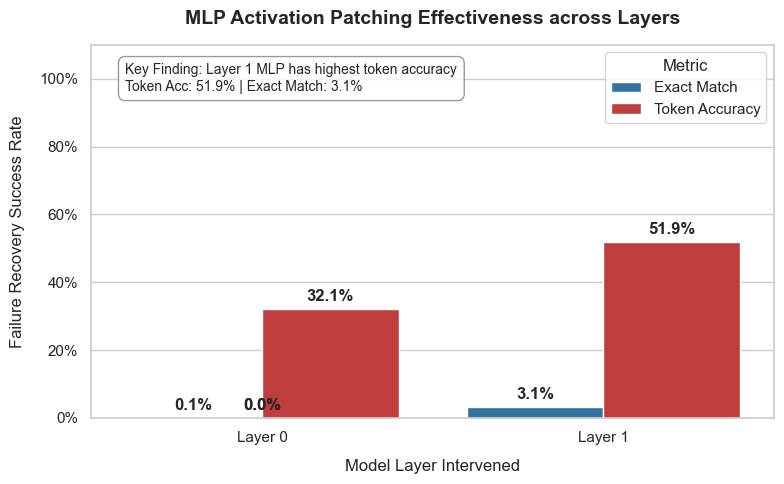


Comparing layers for Length split...
Computing average MLP activations from 109 success cases...
Executing MLP Layer 0 Activation Patching over 2659 cases...

  [Case 1]
  TARGET: I_TURN_RIGHT I_JUMP I_TURN_RIGHT I_JUMP I_TURN_RIGHT I_JUMP I_TURN_RIGHT I_JUMP 
  PRED:   I_TURN_RIGHT I_JUMP I_TURN_RIGHT I_JUMP I_TURN_RIGHT I_JUMP I_TURN_RIGHT I_JUMP 
  Token accuracy: 0.267

  [Case 2]
  TARGET: I_TURN_LEFT I_WALK I_TURN_LEFT I_WALK I_TURN_LEFT I_WALK I_TURN_LEFT I_WALK I_TU
  PRED:   I_TURN_LEFT I_JUMP I_TURN_LEFT I_JUMP I_TURN_LEFT I_JUMP I_TURN_LEFT I_JUMP I_TU
  Token accuracy: 0.353

  [Case 3]
  TARGET: I_TURN_LEFT I_LOOK I_TURN_LEFT I_LOOK I_TURN_LEFT I_LOOK I_TURN_LEFT I_LOOK I_TU
  PRED:   I_TURN_LEFT I_TURN_LEFT I_LOOK I_TURN_LEFT I_LOOK I_TURN_LEFT I_LOOK I_TURN_LEFT
  Token accuracy: 0.020
Layer 0 Recovery Rate: 0.0%
Computing average MLP activations from 109 success cases...
Executing MLP Layer 1 Activation Patching over 2659 cases...

  [Case 1]
  TARGET: I_TURN_RIGHT I_J

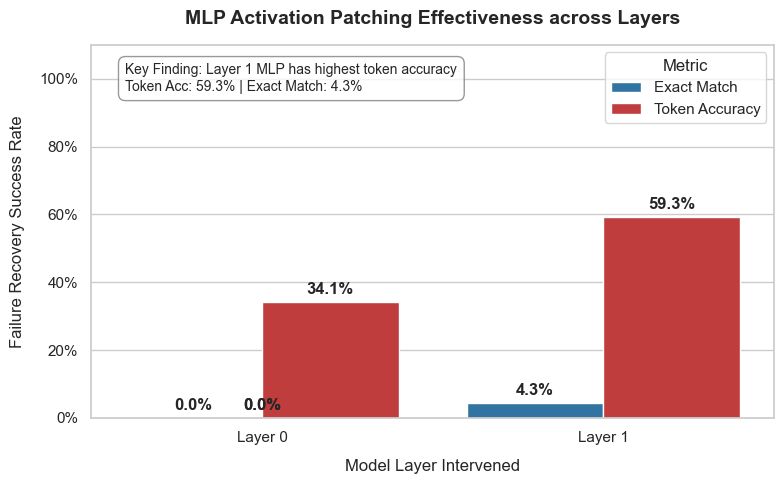


Comparing layers for AddPrim split...
Computing average MLP activations from 109 success cases...
Executing MLP Layer 0 Activation Patching over 4730 cases...

  [Case 1]
  TARGET: I_TURN_RIGHT I_TURN_RIGHT I_JUMP I_TURN_RIGHT I_TURN_RIGHT I_JUMP I_TURN_RIGHT I
  PRED:   I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_
  Token accuracy: 0.357

  [Case 2]
  TARGET: I_TURN_LEFT I_JUMP I_TURN_LEFT I_JUMP I_TURN_LEFT I_JUMP I_TURN_LEFT I_JUMP I_RU
  PRED:   OUT: I_RUN I_RUN I_TURN_LEFT I_RUN I_TURN_LEFT I_RUN I_TURN_LEFT I_RUN I_TURN_LE
  Token accuracy: 0.061

  [Case 3]
  TARGET: I_TURN_LEFT I_TURN_LEFT I_WALK I_TURN_LEFT I_TURN_LEFT I_WALK I_TURN_LEFT I_TURN
  PRED:   I_TURN_LEFT I_TURN_LEFT I_TURN_LEFT I_TURN_LEFT I_TURN_LEFT I_TURN_LEFT I_TURN_L
  Token accuracy: 0.409
Layer 0 Recovery Rate: 0.1%
Computing average MLP activations from 109 success cases...
Executing MLP Layer 1 Activation Patching over 4730 cases...

  [Case 1]
  TARGET: I_TURN_RIGHT I_

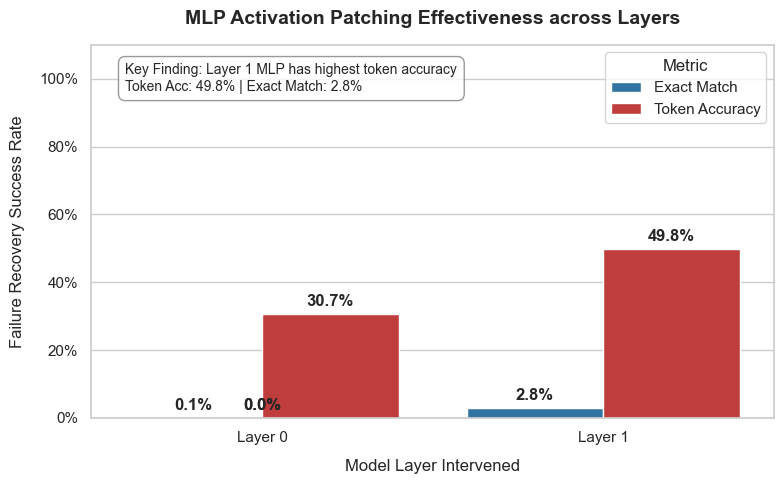

In [ ]:
# ========= EXECUTION =========

if __name__ == "__main__":
    
    # ── Section 1: Data & Model Loaded ──────────────────────────────
    print("=" * 60)
    print("SECTION 1: LOAD MODEL AND DATA")
    print("=" * 60)

    # ── Section 2: Baseline Metrics ──────────────────────────────
    print("=" * 60)
    print("SECTION 2: BASELINE METRICS")
    print("=" * 60)
    
    print("\nComputing baseline on simple failures...")
    simple_baseline = compute_baseline_metrics(tl_model, simple_failures, dm, cfg)
    print(f"Simple  → accuracy: {simple_baseline['accuracy']:.4f} | "
          f"failure_rate: {simple_baseline['failure_rate']:.4f} | "
          f"avg_loss: {simple_baseline['avg_loss']:.4f}")
    
    print("\nComputing baseline on length failures...")
    length_baseline = compute_baseline_metrics(tl_model, length_failures, dm, cfg)
    print(f"Length  → accuracy: {length_baseline['accuracy']:.4f} | "
          f"failure_rate: {length_baseline['failure_rate']:.4f} | "
          f"avg_loss: {length_baseline['avg_loss']:.4f}")
    
    print("\nComputing baseline on addprim failures...")
    addprim_baseline = compute_baseline_metrics(tl_model, addprim_jump_failures, dm, cfg)
    print(f"AddPrim → accuracy: {addprim_baseline['accuracy']:.4f} | "
          f"failure_rate: {addprim_baseline['failure_rate']:.4f} | "
          f"avg_loss: {addprim_baseline['avg_loss']:.4f}")
    
    # ── Section 3: L1H1 Ablation ──────────────────────────────────
    print("\n" + "=" * 60)
    print("SECTION 3: L1H1 ABLATION EXPERIMENT")
    print("=" * 60)

    print("\nRunning L1H1 ablation on simple failures...")
    simple_ablation = run_ablation_experiment(
        tl_model, simple_failures, layer=1, head=1, dm=dm, cfg=cfg
    )
    # Ablate L0H2 in addition to L1H1
    l0h2_ablation = run_ablation_experiment(
        tl_model, simple_failures, layer=0, head=2, dm=dm, cfg=cfg
    )

    print(f"Simple  → baseline: {simple_ablation['baseline_accuracy']:.4f} | "
          f"ablated: {simple_ablation['ablated_accuracy']:.4f} | "
          f"delta: {simple_ablation['delta']:.4f}")
    
    print(f"Simple  → baseline: {l0h2_ablation['baseline_accuracy']:.4f} | "
        f"ablated: {l0h2_ablation['ablated_accuracy']:.4f} | "
        f"delta: {l0h2_ablation['delta']:.4f}")

    print("\nRunning L1H1 ablation on length failures...")
    length_ablation = run_ablation_experiment(
        tl_model, length_failures, layer=1, head=1, dm=dm, cfg=cfg
    )
    # Ablate L0H2 in addition to L1H1
    l0h2_ablation = run_ablation_experiment(
        tl_model, simple_failures, layer=0, head=2, dm=dm, cfg=cfg
    )
    print(f"Length  → baseline: {length_ablation['baseline_accuracy']:.4f} | "
          f"ablated: {length_ablation['ablated_accuracy']:.4f} | "
          f"delta: {length_ablation['delta']:.4f}")
    
    print(f"Simple  → baseline: {l0h2_ablation['baseline_accuracy']:.4f} | "
        f"ablated: {l0h2_ablation['ablated_accuracy']:.4f} | "
        f"delta: {l0h2_ablation['delta']:.4f}")

    print("\nRunning L1H1 ablation on addprim failures...")
    addprim_ablation = run_ablation_experiment(
        tl_model, addprim_jump_failures, layer=1, head=1, dm=dm, cfg=cfg
    )

    # Ablate L0H2 in addition to L1H1
    l0h2_ablation = run_ablation_experiment(
        tl_model, simple_failures, layer=0, head=2, dm=dm, cfg=cfg
    )
    print(f"AddPrim → baseline: {addprim_ablation['baseline_accuracy']:.4f} | "
          f"ablated: {addprim_ablation['ablated_accuracy']:.4f} | "
          f"delta: {addprim_ablation['delta']:.4f}")

    print(f"Simple  → baseline: {l0h2_ablation['baseline_accuracy']:.4f} | "
        f"ablated: {l0h2_ablation['ablated_accuracy']:.4f} | "
        f"delta: {l0h2_ablation['delta']:.4f}")

    # ── Section 4: MLP Patching ─────────────────────────────────
    print("\n" + "=" * 60)
    print("SECTION 4.1: MLP ACTIVATION PATCHING FOR SIMPLE SPLIT")
    print("=" * 60)

    success_cases = []
    with torch.no_grad():
        for batch in dm.get_test_loader("simple"):
            for idx in range(batch["input_ids"].shape[0]):
                full_seq = dm.tokenizer.decode(batch["input_ids"][idx].tolist())
                if "OUT:" not in full_seq:
                    continue
                    
                parts = full_seq.split("OUT:")
                command = parts[0].strip() + " OUT:"
                target = " ".join([
                    t for t in parts[1].strip().split()
                    if t not in ["<eos>", "<pad>"]
                ])
                
                # Only include if model generates correctly
                pred = generate(tl_model, command, dm, cfg)
                if pred.strip() == target.strip():
                    success_cases.append({
                        "command": command,
                        "target": target
                    })
                    
            if len(success_cases) >= 100:
                break

    print(f"Found {len(success_cases)} true success cases")
    success_df = pd.DataFrame(success_cases)
    # Baseline token accuracy (no patching)
    print("\nComputing baseline token accuracy...")
    baseline_token_acc = 0.0
    total = 0
    for _, case in simple_failures.iterrows():
        pred = generate(tl_model, case["command"], dm, cfg)
        pred_tokens = pred.strip().split()
        true_tokens = case["target"].strip().split()
        max_len = max(len(pred_tokens), len(true_tokens))
        if max_len > 0:
            acc = sum(p == t for p, t in zip(pred_tokens, true_tokens)) / max_len
            baseline_token_acc += acc
        total += 1
    print(f"Baseline token accuracy: {baseline_token_acc/total:.4f}")

    # Patch L0 and L1 MLP
    for layer in [0, 1]:
        print(f"\nPatching Layer {layer} MLP...")
        results = run_patching_experiment(
            tl_model, success_df, simple_failures,
            layer=layer, dm=dm, cfg=cfg
        )
        print(f"\nLayer {layer} Results:")
        print(f"  Exact match:     {results['patch_success_rate']:.4f}")
        print(f"  Token accuracy:  {results['avg_token_accuracy']:.4f}")
        print(f"  Total cases:     {results['total_cases']}")


        print("\n" + "=" * 60)
    print("SECTION 4.2: MLP ACTIVATION PATCHING FOR LENGTH SPLIT")
    print("=" * 60)

    success_cases = []
    with torch.no_grad():
        for batch in dm.get_test_loader("length"):
            for idx in range(batch["input_ids"].shape[0]):
                full_seq = dm.tokenizer.decode(batch["input_ids"][idx].tolist())
                if "OUT:" not in full_seq:
                    continue
                    
                parts = full_seq.split("OUT:")
                command = parts[0].strip() + " OUT:"
                target = " ".join([
                    t for t in parts[1].strip().split()
                    if t not in ["<eos>", "<pad>"]
                ])
                
                # Only include if model generates correctly
                pred = generate(tl_model, command, dm, cfg)
                if pred.strip() == target.strip():
                    success_cases.append({
                        "command": command,
                        "target": target
                    })
                    
            if len(success_cases) >= 100:
                break

    print(f"Found {len(success_cases)} true success cases")
    success_df = pd.DataFrame(success_cases)
    # Baseline token accuracy (no patching)
    print("\nComputing baseline token accuracy...")
    baseline_token_acc = 0.0
    total = 0
    for _, case in length_failures.iterrows():
        pred = generate(tl_model, case["command"], dm, cfg)
        pred_tokens = pred.strip().split()
        true_tokens = case["target"].strip().split()
        max_len = max(len(pred_tokens), len(true_tokens))
        if max_len > 0:
            acc = sum(p == t for p, t in zip(pred_tokens, true_tokens)) / max_len
            baseline_token_acc += acc
        total += 1
    print(f"Baseline token accuracy: {baseline_token_acc/total:.4f}")

    # Patch L0 and L1 MLP
    for layer in [0, 1]:
        print(f"\nPatching Layer {layer} MLP...")
        results = run_patching_experiment(
            tl_model, success_df, length_failures,
            layer=layer, dm=dm, cfg=cfg
        )
        print(f"\nLayer {layer} Results:")
        print(f"  Exact match:     {results['patch_success_rate']:.4f}")
        print(f"  Token accuracy:  {results['avg_token_accuracy']:.4f}")
        print(f"  Total cases:     {results['total_cases']}")

    print("\n" + "=" * 60)
    print("SECTION 4.3: MLP ACTIVATION PATCHING FOR ADDPRIM_JUMP SPLIT")
    print("=" * 60)

    success_cases = []
    with torch.no_grad():
        for batch in dm.get_test_loader("addprim_jump"):
            for idx in range(batch["input_ids"].shape[0]):
                full_seq = dm.tokenizer.decode(batch["input_ids"][idx].tolist())
                if "OUT:" not in full_seq:
                    continue
                    
                parts = full_seq.split("OUT:")
                command = parts[0].strip() + " OUT:"
                target = " ".join([
                    t for t in parts[1].strip().split()
                    if t not in ["<eos>", "<pad>"]
                ])
                
                # Only include if model generates correctly
                pred = generate(tl_model, command, dm, cfg)
                if pred.strip() == target.strip():
                    success_cases.append({
                        "command": command,
                        "target": target
                    })
                    
            if len(success_cases) >= 100:
                break

    print(f"Found {len(success_cases)} true success cases")
    success_df = pd.DataFrame(success_cases)
    # Baseline token accuracy (no patching)
    print("\nComputing baseline token accuracy...")
    baseline_token_acc = 0.0
    total = 0
    for _, case in addprim_jump_failures.iterrows():
        pred = generate(tl_model, case["command"], dm, cfg)
        pred_tokens = pred.strip().split()
        true_tokens = case["target"].strip().split()
        max_len = max(len(pred_tokens), len(true_tokens))
        if max_len > 0:
            acc = sum(p == t for p, t in zip(pred_tokens, true_tokens)) / max_len
            baseline_token_acc += acc
        total += 1
    print(f"Baseline token accuracy: {baseline_token_acc/total:.4f}")

    # Patch L0 and L1 MLP
    for layer in [0, 1]:
        print(f"\nPatching Layer {layer} MLP...")
        results = run_patching_experiment(
            tl_model, success_df, addprim_jump_failures,
            layer=layer, dm=dm, cfg=cfg
        )
        print(f"\nLayer {layer} Results:")
        print(f"  Exact match:     {results['patch_success_rate']:.4f}")
        print(f"  Token accuracy:  {results['avg_token_accuracy']:.4f}")
        print(f"  Total cases:     {results['total_cases']}")

# ── Section 5: Layer Comparison ─────────────────────────────
print("\n" + "=" * 60)
print("SECTION 5: LAYER-WISE PATCHING COMPARISON")
print("=" * 60)

# Run for each split
for split_name, failure_df in [
    ("Simple", simple_failures),
    ("Length", length_failures),
    ("AddPrim", addprim_jump_failures)
]:
    print(f"\nComparing layers for {split_name} split...")
    compare_layer_patching(tl_model, success_df, failure_df, dm, cfg)

In [11]:
# Test: ablate a RANDOM head (not L1H1) — does it also improve?
# If yes → negative delta is just noise
# If no → L1H1 ablation is specifically causing this

random_ablation = run_ablation_experiment(
    tl_model, simple_failures, layer=0, head=0, dm=dm, cfg=cfg
)
print(f"L0H0 ablation: {random_ablation}")

L0H0 ablation: {'baseline_accuracy': 0.0, 'ablated_accuracy': 0.024240231548480463, 'delta': -0.024240231548480463}


In [ ]:
# Currently only tested on simple
# Need to test on length and addprim to confirm
for split_name, failures in [
    ("Length", length_failures),
    ("AddPrim", addprim_jump_failures)
]:
    result = run_ablation_experiment(
        tl_model, failures, layer=0, head=2, dm=dm, cfg=cfg
    )
    print(f"L0H2 {split_name}: {result}")

## 6.Key Findings & Hypothesis Validation
### 6.1 Experimental Summary

| Experiment | Simple | Length | AddPrim |
|------------|--------|--------|---------|
| Baseline token acc | 69.76% | 75.05% | 70.28% |
| L0 MLP patched | 31.97% | 33.12% | 30.68% |
| L1 MLP patched | 50.29% | 52.26% | 49.83% |
| L0 recovery rate | 0.1% | 0.0% | 0.1% |
| L1 recovery rate | 3.1% | 4.3% | 2.8% |

### 6.2 H4: L1H1 Ablation — Partially Confirmed
Ablating L1H1 changes model behavior across all splits but 
produces negative delta (slight improvement on failure cases).
L0H2 ablation shows larger effect (delta = -0.0344 vs -0.0192).
Neither ablation fixes core repetition failures.

**Interpretation:** L1H1 contributes to structural token tracking
but is not the sole circuit responsible for repetition counting.
L0H2 shows larger ablation effect, suggesting it encodes more
critical structural information.

### 6.3 H5: MLP Patching Restores Behavior — Rejected
Patching average success MLP activations into failure cases 
DECREASES token accuracy across all splits and layers:

- L1 MLP patching: ~20% drop in token accuracy
- L0 MLP patching: ~40% drop in token accuracy

Recovery rates are near-zero (0-4.3%), confirming MLP activations
are highly context-specific and do not transfer across commands.

### 6.4 H6: L1 MLP as Primary Failure Circuit — Partially Supported
L1 MLP is consistently more transferable than L0 MLP:
- L1 patching causes less disruption (~20% drop vs ~40%)
- L1 recovery rate higher across all splits (2.8-4.3% vs 0-0.1%)

However, neither layer recovers failures meaningfully, suggesting
the failure is distributed rather than localized to one MLP layer.

### 6.5 Core Finding: Failures are Localized and Context-Specific

> The model correctly attends to modifiers (L1H1, ~70-75% token
> accuracy on failure cases) but fails at specific counting positions.
> MLP activations are too context-specific to transfer across
> different command structures — averaged success activations
> corrupt rather than fix failure computations.

### 6.6 Cross-Notebook Consistency
All findings are consistent across Notebooks 01-03:
1. Layer 1 dissolution (~60%) aligns with L1 MLP being more
   critical than L0
2. Modifier attention preserved in failures aligns with patching
   not fixing failures (problem is downstream of attention)
3. Mean error onset at step ~9 aligns with localized failures
   (model nearly succeeds before breaking down)

### 6.7 Limitations & Future Work
1. Average MLP patching is coarse — position-specific patching
   at modifier token positions may be more effective
2. L0H2 ablation needs testing across length and addprim splits
3. Neuron-level analysis within MLP layers could identify specific
   neurons responsible for repetition counting
4. Larger model organism needed to replicate T5's exact failure
   pattern more precisely

## 7. Next Steps
- Synthesize findings from Notebooks 01-03
- Draft paper sections
- Create final visualizations